In [606]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler, RobustScaler
from scipy.stats import normaltest
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages

In [607]:
df=pd.read_csv('../data/dataset_collection.csv')

In [608]:
df

,URUT,R1301A,R1301B,R1301C,R1303A,R1303B,R1303C,R1305A,R1305B,R1305C,...,R1206B,R1207,R1208,R1209,R1210A,R1210B,R1210C,R1210D,R1210E,index_k
0,1,1,1,1,4,1,4,1,2,2,...,2,1,2,3,2,2,1,1,2,62.31
1,2,1,2,2,4,1,2,4,2,2,...,3,1,2,4,1,2,1,1,2,72.21
2,3,1,1,2,1,1,4,4,1,2,...,2,1,2,4,2,2,1,2,2,70.80
3,4,1,1,2,2,1,2,2,2,2,...,3,2,4,2,2,2,2,1,2,72.89
4,5,1,1,2,4,1,2,2,2,2,...,2,4,2,3,1,2,2,1,2,72.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74679,74680,1,1,3,1,1,1,1,1,1,...,2,1,3,4,1,1,1,1,1,64.53
74680,74681,1,1,3,1,1,1,1,1,1,...,2,1,3,4,1,1,1,1,1,72.00
74681,74682,1,1,2,1,1,1,1,1,1,...,2,1,2,4,1,1,1,1,1,61.60
74682,74683,1,1,3,1,1,1,1,1,1,...,2,1,3,1,1,2,1,1,2,61.48


# handling missing value 
> dengan mean/median/modus

Kolom data sparse (Data Kosong/atau telah ditentukan) karena skip logic
1.  R601B1, R601B2 => Jika R601A = 1 categorical nominal | Mengisi nilai kolom R601B1 jika R601A bernilai 4 (Berkerja)

2.  R602A1,R602A2,R602B,R603,R604A,R604B,R604C,R604D,R604E,R604F,R604G,R605 => Jika R601A

3.  R609C => Jika R609B = 1,2

4.  R701B => Jika R701A = 1

5.  R702B => Jika R702A = 2

6.  R703A1, R703A2 => Jika R701A berkode 1 dan R702A berkode 2 [standarisasi binary]

7.  R703B => Jika R701A berkode 2, 3, 4 atau R702A berkode 1, Atau R703A1 = 2 dan R703A2 = 2

8.  R705B1, R705B2, R705B3, R705B4, R705B5, R705B6 => Jika R705A = 2

9.  R902B1, R902B2, R902B3, R902B4, R902B5, R902C => Jika R902A = 00

10. R1103BK2, R1103BK3, R1103BK4, R1103BK5, R1103BK6, R1103BK7, R1103CK2, R1103CK3, R1103CK4, R1103CK5, R1103CK6, R1103CK7, R1103DK2, R1103DK3, R1103DK4, R1103DK5, R1103DK6, R1103DK7, R1103EK2, R1103EK3, R1103EK4, R1103EK5, R1103EK6, R1103EK7, R1103FK2, R1103FK3, R1103FK4, R1103FK5, R1103FK6, R1103FK7, R1103GK2, R1103GK3, R1103GK4, R1103GK5, R1103GK6, R1103GK7, R1103HK2, R1103HK3, R1103HK4, R1103HK5, R1103HK6, R1103HK7, R1103IK2, R1103IK3, R1103IK4, R1103IK5, R1103IK6, R1103IK7, R1103JK2, R1103JK3, R1103JK4, R1103JK5, R1103JK6, R1103JK7

11. R1601A, R1601B => Jika R1206A = 3

12. R1604B => Jika R1604A = 2

13. R1607B => Jika R1607A = 1, 2, 3

14. R1608B => Jika R1608A = 1 

15. R1608C => Jika R1608A = 2

16. R1609B1, R1609B2, R1609B3, R1609B4, R1609B5, R1609B6 => Jika R1609A = 2

17. R1609C => Jika Jika R1609A = 1 dan salah satu R1609B1-6 = 1

18. R1613B => Jika R1613A != 1

19. R1613C => Jika R1613A != 2


In [609]:
missing = df.isnull().sum()
print("\nJumlah Missing Values:")
missing[missing > 0]


Jumlah Missing Values:


R1601A       1067
R1601B       1067
R1604B      13133
R1607B      16669
R1608B      53025
            ...  
R1103FK7    74230
R1103GK7    74230
R1103HK7    74230
R1103IK7    74230
R1103JK7    74292
Length: 99, dtype: int64

## Kolom Kategorical (Text)

Mising value pada data kategorical tidak diisi, karena akan dilakukan onehot encoding dan di input 0

### kolom R1607B, R1608C, R1609C

In [610]:
def encodeData(df, column,  references):
    # Loop melalui setiap huruf dalam daftar referensi
    for i, letter in enumerate(references):
        # Nama kolom baru akan menjadi R1607B_Huruf (misal: R1607B_A, R1607B_B)
        # Menggunakan f-string untuk membuat nama kolom dinamis
        # Menggunakan underscore untuk keterbacaan
        column_name = f'{column}_{letter}'
        df[column_name] = df[column].apply(
            lambda x: 0 if pd.isna(x) else (1 if letter in str(x) else 0)
        )
        
# Referensi huruf
references = ['A', 'B', 'C', 'D', 'E', 'F', 'X'] # untuk kolom R1607B
references2 = ['A', 'B', 'C', 'D', 'E', 'F'] # untuk kolom R1608C, R1609C

encodeData(df, 'R1607B', references)
encodeData(df, 'R1608C', references2)
encodeData(df, 'R1609C', references2)

df.loc[df['R1607A'].isin([4,5]), ['R1607B','R1607B_A', 'R1607B_B', 'R1607B_C', 'R1607B_D', 'R1607B_E', 'R1607B_F', 'R1607B_X']].head()

,R1607B,R1607B_A,R1607B_B,R1607B_C,R1607B_D,R1607B_E,R1607B_F,R1607B_X
4,D,0,0,0,1,0,0,0
5,B,0,1,0,0,0,0,0
6,C,0,0,1,0,0,0,0
7,D,0,0,0,1,0,0,0
8,D,0,0,0,1,0,0,0


In [611]:
df[[
	'R1607B', 'R1607B_A', 'R1607B_B', 'R1607B_C', 'R1607B_D', 'R1607B_E', 'R1607B_F', 'R1607B_X',
	'R1608C','R1608C_A', 'R1608C_B', 'R1608C_C', 'R1608C_D', 'R1608C_E', 'R1608C_F', 
	'R1609C', 'R1609C_A', 'R1609C_B', 'R1609C_C', 'R1609C_D', 'R1609C_E', 'R1609C_F'
]].isnull().sum()[lambda x: x > 0]

R1607B    16669
R1608C    21659
R1609C    48158
dtype: int64

In [612]:
#  drop column yang tidak terpakai
df.drop(columns=['R1607B', 'R1608C', 'R1609C'], inplace=True)

### kolom R702B (data penyakit)

In [613]:
# Kategori penyakit yang sudah disiapkan
categories = {
    "Penyakit Jantung dan Pembuluh Darah": ["sering pingsan tiba-tiba","pembekakan pembuluh darah","penyumbatan pembuluh darah","tensi","darah rendah","drop darah","penyempitan pembuluh darah","tensi tinggi","kurtosis aorta", "jantung", "koroner", "hipertensi", "tekanan darah tinggi","darah tinggi", "aritmia", "gagal jantung","penyumbatan darah"],
    "Penyakit Sistem Pernafasan": ["paru","afses paru","paru-paru","rinitis","faringitis","meniere syndrome","ispa","radang nasofaring","osa","nafas pendek","alergi dingin","tb","infeksi hidung","alergi asap","radang tenggorokan","covid","saluran pernafasan","peradangan paru","alergi debu","penyempitan pernafasan","tbc","sinusitis","polip", "amandel","step","tipes","sesak","sinositis","sesak nafas","asma", "bronkitis", "pneumonia", "copd"],
    "Penyakit Metabolik": ["kekurangan kalium","anemia","kencing manis","lemak darah","diabetes", "diabetes melitus", "kolesterol", "asam urat", "gout", "hiperlipidemia","gula darah","gula"],
    "Penyakit Tulang, Otot, dan Sendi": ["bengkak otot","kaki","avn","hnp","luka di kaki","kaki  terluka","pincang","otot bahu","kaki terluka","kolagen","cacat kaki","radang otot kaki","osteoarthrotis","punggung","kaki mudah merasa lemas","kaki selalu terasa lemas","hernea","sendi","gangguan persendian","kelelahan otot", "di bagin kaki","kesulitan untuk berjalan", "cacat pincang", "osteoritis","radang sendi","lutut","pengapuran","pinggang", "tulang", "hernia","patah kaki","osteoporosis", "artritis", "skoliosis", "fibromyalgia", "rematik"],
    "Penyakit Kanker dan Tumor": ["pembengkakan payudara","leukimia","kangker payudara","kista","kanker", "melanoma", "tumor","kangker perut"],
    "Penyakit Sistem Pencernaan": ["bagian perut","perut bengkak ( ada genangan air dlm perut )","pencernaan","berak darah","muntah darah","gangguan pencernaan","infeksi saluran pencernaan","empedu","refluks gastroesofagus","usus turung","pencernaan usus","gangguan empedu","kram usus", "liver","susah buang air besar", "radang usus", "empedu mengandung lemak dan lumpur","alergi saluran pencernaan","infeksi usus","tifus","peti liver","kuning","ambeyen", "hati","asam lambung","lambung", "maag", "gastritis", "batu empedu", "hepatitis", "ibs","usus buntu","gangguan usus"],
    "Penyakit Mata": ["ablosio retina", "tuna netra", "mata","katarak", "glaukoma", "konjungtivitis", "degenerasi makula", "buta","rabun"],
    "Penyakit Ginjal dan Saluran Kemih": ["kencing tidak lancar","infeksi saluran kemih","radang kencing","penyempitan saluran ginjal","gangguan saluran kencing","kencing batu","kencing frostat","ginjal", "batu ginjal", "isk", "gagal ginjal", "nefritis","infeksi saluran kencing"],
    "Penyakit Sistem Saraf dan Kejiwaan": ["pencairan di otak","jiwa","meningitis","tremor","gangguan jiwa","bisu","kejang","saraf terjepit","tekanan jiwa","kepala", "migrain","insomnia", "encephalitis","susah tidur", "vertigo","saraf","penyempitan saraf","epilepsi", "skizofrenia", "stroke", "depresi","mental","lumpuh","kejiwaan"],
    "Lainnya": ["kurang kalsium", "theroid","tiroid","teroid","hiperteroid","kelenjar","gondok","gondog","komplikasi","malaria","prostat","tiroit","autoimun","infeksi kulit yg parah","ada miom di rahim","keguguran","kelainan fisik","telinga pokak","kurang pendengaran","kelenjar leher","kaki bengkak spt kaki gajah  hanya saja bukan  kaki gajah","radang payudara","kulit","trauma menyeluruh","endometriosis","beri-beri","endometriosis","benjolan di leher","benjolan dileher","batuk","endrometriosis","prostat","porstat","tahunan","sel darah putih","miom habis operasi 6 bulan yllu","exim","maaf kronis","eksim","demam panas","dalam","terahum","pengangkatan rahim","kehamilan abdomen","kusta basah","gatal-gatal yang tidak bisa sembuh","virus tokso dinyatakan oleh dokter bahaya jika kalau hamil","hidroteroit","bulanan tidak normal","miyoma","miyoum","mioma","hypertirod","alergi semen","alergi","takanan","kronis","typoid","miom","kelebihan hormon","tekanan","pengobatan 6 bulan","payudara","gatal gatal","tidak bisa jalan","tua tdk bs jalan","dikarenakan umur yg sudah tua"],
}

# Fungsi memuat peta kesalahan ketik (typo_map)
def load_typo_map(file_path):
    typo_map = {}
    with open(file_path, 'r') as file:
        for line in file:
            typo, correct = line.strip().split('|')
            typo_map[typo] = correct
    return typo_map

# Muat peta kesalahan ketik
typo_map = load_typo_map('../data/typo_map.txt')

# Fungsi normalisasi teks dengan memperbaiki typo menggunakan typo_map
def normalize_text(text, typo_map):
    # Pertama, ganti typo berdasarkan typo_map
    text = text.lower()
    for typo, correct in typo_map.items():
        text = text.replace(typo, correct)
    
    # Lakukan normalisasi lainnya
    return text.replace(" dan ", ",").replace("&", ",").replace("/", ",").replace(".", " ").strip()

# Fungsi pemrosesan baris data untuk kategorisasi penyakit
def process_row(entry, typo_map, categories):
    normalized_entry = normalize_text(entry, typo_map)
    normalized_diseases = [disease.strip() for disease in normalized_entry.split(",")]

    
    # Pemetaan kategori untuk setiap penyakit
    result = {category: 0 for category in categories.keys()}  # Default 0 (tidak)
    result['normalize_R702B'] = normalized_entry
    for disease in normalized_diseases:
        for category, keywords in categories.items():
            if any(keyword in disease for keyword in keywords):
                result[category] = 1  # 1 (ya)
    
    return result

# Fungsi utama untuk memproses dan menambahkan hasil ke df_combined
def process_and_add_to_df(df_combined, typo_map, categories):
    results = []

    # Proses setiap baris pada df_combined berdasarkan 'R702A' == "1"
    for entry in df_combined.loc[df_combined['R702A'] == 1, 'R702B']:
        result = process_row(entry, typo_map, categories)
        results.append(result)

    # Buat DataFrame hasil
    df_results = pd.DataFrame(results)

    # Kolom yang akan ditambahkan ke df_combined adalah hasil kategori R702A1 hingga R702A11
    df_combined_results = df_combined.loc[df_combined['R702A'] == 1].copy()

    # Menambahkan hasil kategori ke df_combined_results
    df_combined_results = df_combined.loc[df_combined['R702A'] == 1].copy().reset_index(drop=True)
    df_results = df_results.drop(columns=["normalize_R702B"])
    df_results = df_results.reset_index(drop=True)
    for i, column in enumerate(df_results.columns):
        new_column_name = f"R702B_{i+1}"
        df_combined_results[new_column_name] = df_results[column]

    # Menambahkan kolom R702B_1 hingga R702B_11 dengan nilai default 0 untuk baris lainnya
    for i in range(1, len(categories.keys()) + 1):
        column_name = f"R702B_{i}"
        if column_name not in df_combined.columns:
            df_combined[column_name] = 0

    # Gabungkan kembali dengan data df_combined
    df_combined_others = df_combined[df_combined['R702A'] != 1].copy()
    df_combined_final = pd.concat([df_combined_others, df_combined_results], ignore_index=True)

    return df_combined_final



# Proses dan tambahkan ke df_combined
df = process_and_add_to_df(df, typo_map, categories)
print(df.shape)

(74684, 284)


In [614]:
missing_values = df[['R702B_1', 'R702B_2', 'R702B_3', 'R702B_4', 'R702B_5', 'R702B_6', 'R702B_7', 'R702B_8', 'R702B_9', 'R702B_10']].isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values

Series([], dtype: int64)

In [615]:
# drop column yang tidak terpakai
df.drop(columns=['R702B'], inplace=True)

In [616]:
df[['R702B_1', 'R702B_2', 'R702B_3', 'R702B_4', 'R702B_5', 'R702B_6', 'R702B_7', 'R702B_8', 'R702B_9', 'R702B_10']].describe()

,R702B_1,R702B_2,R702B_3,R702B_4,R702B_5,R702B_6,R702B_7,R702B_8,R702B_9,R702B_10
count,74684.000000,74684.000000,74684.000000,74684.000000,74684.000000,74684.000000,74684.000000,74684.000000,74684.000000,74684.000000
mean,0.024276,0.010538,0.022401,0.004084,0.001620,0.017514,0.000616,0.002008,0.006628,0.005302
std,0.153905,0.102112,0.147985,0.063775,0.040219,0.131177,0.024810,0.044771,0.081142,0.072624
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Sisa Mising Value
> bertipe semua nominal

In [617]:
missing = df.isnull().sum()
print("\nJumlah Missing Values:")
missing[missing > 0]


Jumlah Missing Values:


R1601A       1067
R1601B       1067
R1604B      13133
R1608B      53025
R1609B1     25207
            ...  
R1103FK7    74230
R1103GK7    74230
R1103HK7    74230
R1103IK7    74230
R1103JK7    74292
Length: 95, dtype: int64

In [618]:
df_filled_with_mode = df.apply(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x)

In [619]:
missing = df_filled_with_mode.isnull().sum()
print("\nJumlah Missing Values:")
missing[missing > 0]


Jumlah Missing Values:


Series([], dtype: int64)

In [620]:
numeric_cols = df_filled_with_mode.select_dtypes(include='number').columns
numeric_cols = [col for col in numeric_cols if col not in ['URUT', 'WEIGHT']]
for kolom in numeric_cols:
	data = df_filled_with_mode[kolom]
	if data.max() == data.min():
		print(kolom)

R1103FK6


In [621]:
df_filled_with_mode['R1103FK6'].describe()

count    74684.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: R1103FK6, dtype: float64

In [622]:
# data di drop karena tidak memiliki variansi atau std = 0
df_filled_with_mode.drop(['R1103FK6'], axis=1, inplace=True)

# UJI NORMALITAS

## D'Agostino and Pearson's test (Normaltest)

In [623]:
normal_columns = []

# Loop semua kolom numerik
for col in df_filled_with_mode.select_dtypes(include='number').columns:
    data = df_filled_with_mode[col].dropna()

    # Lewati jika jumlah data kurang dari 8 atau variansi terlalu kecil
    if len(data) < 8 or data.std() < 1e-8:
        continue

    stat, p = normaltest(data)
    if p > 0.05:
        normal_columns.append({
            'kolom': col,
            'stat': stat,
            'p_value': p
        })


# Tampilkan hasil kolom normal dalam DataFrame
df_normal = pd.DataFrame(normal_columns)
df_normal

""


## Shapiro-Wilk Test

In [624]:
normal_columns = []
# Sampling 5000 baris acak
df_sampled = df_filled_with_mode.sample(n=5000, random_state=42)

for col in df_sampled.select_dtypes(include='number').columns:
    data = df_sampled[col].dropna()

    # Lewati kolom jika data kurang dari 3 atau range = 0
    if len(data) < 3 or data.max() == data.min():
        continue

    stat, p = shapiro(data)
    if p > 0.05:
        normal_columns.append({
            'kolom': col,
            'stat': stat,
            'p_value': p
        })

# Tampilkan dalam bentuk DataFrame
df_normal = pd.DataFrame(normal_columns)
df_normal

""


In [625]:
df_filled_with_mode.shape

(74684, 282)

## Sebaran distribusi setiap kolom

In [626]:
def plot_distribusi_pdf(df_, exclude_columns=None, output_file='distribusi_output.pdf'):
    if exclude_columns is None:
        exclude_columns = []

    numeric_cols = df_.select_dtypes(include='number').columns
    numeric_cols = [col for col in numeric_cols if col not in exclude_columns]

    with PdfPages(output_file) as pdf:
        for kolom in numeric_cols:
            data = df_[kolom].dropna()

            # Lewati jika jumlah data < 3 atau semua nilai sama
            if len(data) < 3 or data.max() == data.min():
                continue

            fig, axs = plt.subplots(1, 2, figsize=(12, 5))

            # Histogram + KDE
            sns.histplot(data, kde=True, ax=axs[0], bins=30, color='skyblue')
            axs[0].set_title(f'Histogram + KDE: {kolom}')
            axs[0].set_xlabel(kolom)
            axs[0].set_ylabel('Frequency')

            # Q-Q Plot
            stats.probplot(data, dist="norm", plot=axs[1])
            axs[1].set_title(f'Q-Q Plot: {kolom}')

            plt.tight_layout()
            pdf.savefig(fig)  # Simpan halaman ke PDF
            plt.close(fig)     # Tutup figure agar tidak muncul berulang

    print(f"Selesai. Semua plot disimpan ke '{output_file}'.")

# ✅ Jalankan
# plot_distribusi_pdf(df_filled_with_mode, exclude_columns=['URUT', 'WEIGHT'])


# Encoding

In [627]:
df_encode = df_filled_with_mode.copy()
# Data dipisah setiap jenis data
kolom_kategorikal_nominal = [ # data yang tidak memiliki hirarki, misal tempat bekerja => 1. petani, 2. nelayan, 4. karyawan dll
    "R601B1", "R602A1", "R602A2", "R703B", "R902C", "R1201", "R1205", "R1608B", "R1613B",
    'R1103BK2', 'R1103BK3', 'R1103BK4', 'R1103BK5', 'R1103BK6', 'R1103BK7', 
	'R1103DK2', 'R1103DK3', 'R1103DK4', 'R1103DK5', 'R1103DK6', 'R1103DK7', 
	'R1103FK2', 'R1103FK3', 'R1103FK4', 'R1103FK5', 'R1103FK7', 
	'R1103GK2', 'R1103GK3', 'R1103GK4', 'R1103GK5', 'R1103GK6', 'R1103GK7', 
	'R1103JK2', 'R1103JK3', 'R1103JK4', 'R1103JK5', 'R1103JK6', 'R1103JK7'
]

kolom_kategorikal_ordinal = [ # data yang memiliki tingkatan dalam nilai nya, misal pendidikan => 1. Sd, 3. Smp dll
    "R501", "R504A", "R504B", "R504C", "R603", "R606", "R607", "R609A", "R609B", "R609C", "R701A", "R701B",
    "R704A", "R704B", "R704C", "R704D", "R704E", "R704F", "R704G", "R704H",
    "R706A", "R706B", "R706C", "R706D", "R706E", "R706F", "R706G", "R706H", "R706I", "R706J", "R707A", "R707B", "R707C",
    "R801A", "R801B", "R801C", "R801D", "R1001A", "R1001B", "R1001C", "R1101C", "R1104A", "R1104B", "R1104C", "R1105",
    "R1106A", "R1106B", "R1107A", "R1107B", "R1203", "R1204", "R1206A", "R1206B", "R1207", "R1208", "R1209",
    "R1301A", "R1301B", "R1301C", "R1303A", "R1303B", "R1303C", "R1305A", "R1305B", "R1305C", "R1305D",
    "R1401A", "R1401B", "R1401C", "R1401D", "R1403A", "R1403B", "R1403C", "R1405A", "R1405B", "R1405C",
    "R1407A", "R1407B", "R1409A", "R1411A", "R1411B", "R1411C", "R1602", "R1603", "R1604B",
    "R1605A", "R1605B", "R1605C", "R1605D", "R1605E", "R1606", "R1607A", "R1610", "R1611", "R1612",
    "R1613A", "R1613C", "R1614", "R1615", "R1616"
]

kolom_biner = [ # memiliki 2 nilai, 1 dan 2
    "R502", "R503", "R601A", "R602B", "R604A", "R604B", "R604C", "R604D", "R604E", "R604F", "R604G", "R608",
    "R702A", "R703A1", "R703A2", "R705A", "R705B1", "R705B2", "R705B3", "R705B4", "R705B5", "R705B6", "R902B1",
    "R902B2", "R902B3", "R902B4", "R902B5", "R1101A1", "R1101A2", "R1101A3", "R1101A4", "R1101A5", "R1101B1",
    "R1101B2", "R1101B3", "R1210A", "R1210B", "R1210C", "R1210D", "R1210E", "R1409B", "R1604A", "R1608A", "R1609A",
    "R1609B1", "R1609B2", "R1609B3", "R1609B4", "R1609B5", "R1609B6",
    'R1103AK2', 'R1103AK3', 'R1103AK4', 'R1103AK5', 'R1103AK6', 'R1103AK7', 
	'R1103CK2', 'R1103CK3', 'R1103CK4', 'R1103CK5', 'R1103CK6', 'R1103CK7', 
	'R1103EK2', 'R1103EK3', 'R1103EK4', 'R1103EK5', 'R1103EK6', 'R1103EK7', 
	'R1103HK2', 'R1103HK3', 'R1103HK4', 'R1103HK5', 'R1103HK6', 'R1103HK7', 
	'R1103IK2', 'R1103IK3', 'R1103IK4', 'R1103IK5', 'R1103IK6', 'R1103IK7'
]

kolom_kategorikal_encoded = [ # data string/text yang telah dikategorikan dan di encode pada tahap prepcessing (sudah biner)
    "R702B_1", "R702B_2", "R702B_3", "R702B_4", "R702B_5", "R702B_6", "R702B_7", "R702B_8", "R702B_9", "R702B_10",
    'R1607B_A', 'R1607B_B', 'R1607B_C', 'R1607B_D', 'R1607B_E', 'R1607B_F', 'R1607B_X',
    'R1609C_A', 'R1609C_B', 'R1609C_C', 'R1609C_D', 'R1609C_E', 'R1609C_F',
    'R1608C_A', 'R1608C_B', 'R1608C_C', 'R1608C_D', 'R1608C_E', 'R1608C_F',
]

# nilai 1 - 10
kolomscoring = [
    "R1003A", "R1003B", "R1003C", "R1003D", "R1003E", "R1003F", "R1003G", "R1003H", "R1003I", "R1003J",
    "R1004A", "R1004B", "R1004C", "R1004D", "R1004E", "R1004F",
    "R1002A", "R1002B", "R1002C", "R1002D", "R1002E", "R1002F", "R1002G", "R1002H", "R1002I", "R1002J"
]

# kolom yang memiliki nilai nominal
kolomnominal = [
    "R1601A",
    "R1601B",
    "R902A",
    "R1202",
    "R901"
]

## Validasi jumlah fitur sesuai

In [628]:
fitur = set(kolom_kategorikal_nominal + kolom_kategorikal_ordinal + kolom_biner + kolom_kategorikal_encoded + kolomnominal + kolomscoring)
print("Jumlah kolom yang diharapkan:", len(fitur)) 
print("Jumlah kolom asal:", len(df_encode.columns))

# Ambil kolom yang ada di df
kolom_df = set(df_encode.columns)

# Cari kolom yang ada di df tetapi tidak ada dalam daftar kolom_kategorikal
kolom_tambahan = kolom_df - fitur

# Tampilkan kolom tersebut
print("Jumlah kolom dalam df yang tidak ada dalam daftar :", len(kolom_tambahan))
print("Kolom dalam df yang tidak ada dalam daftar kategorikal:")
print(kolom_tambahan)

Jumlah kolom yang diharapkan: 278
Jumlah kolom asal: 282
Jumlah kolom dalam df yang tidak ada dalam daftar : 4
Kolom dalam df yang tidak ada dalam daftar kategorikal:
{'index_k_raw', 'URUT', 'index_k', 'WEIGHT'}


In [629]:
# mengubah type float menjadi int
df_encode[kolom_kategorikal_nominal] = df_encode[kolom_kategorikal_nominal].astype(int)
df_encode[kolom_kategorikal_ordinal] = df_encode[kolom_kategorikal_ordinal].astype(int)
df_encode[kolom_biner] = df_encode[kolom_biner].astype(int)
df_encode[kolom_kategorikal_encoded] = df_encode[kolom_kategorikal_encoded].astype(int)
df_encode[kolomnominal] = df_encode[kolomnominal].astype(int)
df_encode[kolomscoring] = df_encode[kolomscoring].astype(int)

## Memperbaiki Nilai Biner

In [630]:
# mengubah nilai 2 di kolom biner menjadi nol

# cek dalam kolom biner yang memiliki nilai bukan 1 dan 2
def find_binary_one_two_columns(df_):
    binary_columns = []
    for col in df_.columns:
        # Cek apakah kolom numerik
        if pd.api.types.is_numeric_dtype(df_[col]):
            unique_values = df_[col].dropna().unique()
            # Cek apakah hanya ada 1 dan 2 di nilai unik
            if set(unique_values) != {1, 2}:
                binary_columns.append(col)
    return binary_columns

kolom_biner_1_2 = find_binary_one_two_columns(df_encode[kolom_biner])
print(f"Kolom yang hanya memiliki nilai biner 1 dan 2 adalah: {kolom_biner_1_2}")

Kolom yang hanya memiliki nilai biner 1 dan 2 adalah: ['R703A2', 'R1101A1', 'R1101A2', 'R1101A3', 'R1101A4', 'R1101A5']


In [631]:
print(df_encode['R703A2'].unique())
print(df_encode['R1101A1'].unique())
print(df_encode['R1101A2'].unique())
print(df_encode['R1101A3'].unique())
print(df_encode['R1101A4'].unique())
print(df_encode['R1101A5'].unique())

[4 3]
[1 2 9]
[2 1 9]
[2 1 9]
[2 1 9]
[2 1 9]


In [632]:
# memperbaiki data bermasalah dan menggantinya dengan data modus
df_encode[['R1101A1', 'R1101A2', 'R1101A3', 'R1101A4', 'R1101A5']] = df_encode[['R1101A1', 'R1101A2', 'R1101A3', 'R1101A4', 'R1101A5']].apply(
    lambda col: col.replace(9, col.mode()[0]) if not col.mode().empty else col
)

# Mengubah nilai di kolom 'R703A2': 3 menjadi 1, dan 4 menjadi 2
df_encode['R703A2'] = df_encode['R703A2'].replace({3: 1, 4: 2})

In [633]:
kolom_biner_1_2 = find_binary_one_two_columns(df_encode[kolom_biner])
print(f"Kolom yang hanya memiliki nilai biner 1 dan 2 adalah: {kolom_biner_1_2}")

Kolom yang hanya memiliki nilai biner 1 dan 2 adalah: []


## Encod Kolom Kategorical nominal

In [634]:
# Membuat instance OneHotEncoder
# handle_unknown='ignore' penting agar tidak error jika ada kategori baru di data testing
# sparse_output=False agar hasilnya berupa array numpy dense (bukan sparse matrix)
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# Melatih encoder dan mengubah data
# Kita perlu memilih kolom yang akan di-encode terlebih dahulu
encoded_data = encoder.fit_transform(df_encode[kolom_kategorikal_nominal])
# Mendapatkan nama-nama kolom baru
encoded_feature_names = encoder.get_feature_names_out(kolom_kategorikal_nominal)
# Membuat DataFrame dari hasil encoding
df_encoded_sklearn = pd.DataFrame(encoded_data, columns=encoded_feature_names)
# Menggabungkan hasil encoding dengan kolom non-kategorikal dari DataFrame asli
# Pertama, drop kolom kategorikal asli
df_non_categorical = df_encode.drop(columns=kolom_kategorikal_nominal)
# Gabungkan
df_final_encode = pd.concat([df_non_categorical, df_encoded_sklearn], axis=1)
df_final_encode


,URUT,R1301A,R1301B,R1301C,R1303A,R1303B,R1303C,R1305A,R1305B,R1305C,...,R1103JK6_8,R1103JK6_9,R1103JK7_1,R1103JK7_2,R1103JK7_3,R1103JK7_4,R1103JK7_5,R1103JK7_6,R1103JK7_7,R1103JK7_9
0,1,1,1,1,4,1,4,1,2,2,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,1,2,2,4,1,2,4,2,2,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,1,1,2,1,1,4,4,1,2,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,1,1,2,2,1,2,2,2,2,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,1,1,2,4,1,2,2,2,2,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74679,74600,1,1,3,1,1,2,2,2,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
74680,74618,1,1,3,1,1,1,1,2,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
74681,74671,1,2,2,3,1,3,1,2,2,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
74682,74673,1,1,3,1,1,2,1,1,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [635]:
df_final_encode.shape

(74684, 476)

# feature scaling

In [636]:
# Daftar kolom yang TIDAK ingin diskalaka
cols_to_exclude = ['index_k_raw', 'URUT', 'index_k', 'WEIGHT']
# Identifikasi kolom yang akan diskalakan
cols_to_scale = [col for col in df_final_encode.columns if col not in cols_to_exclude]
# Pisahkan data yang akan diskalakan dan yang tidak
df_to_scale = df_final_encode[cols_to_scale]
df_excluded = df_final_encode[cols_to_exclude]


## Standar Scaler

In [637]:
scaler_standard = StandardScaler()
df_scaled_standard = scaler_standard.fit_transform(df_to_scale)

# Buat DataFrame hasil scaling
df_scaled_standard = pd.DataFrame(df_scaled_standard, columns=cols_to_scale, index=df_final_encode.index)

# Gabungkan kembali dengan kolom yang dikecualikan
df_final_standard = pd.concat([df_scaled_standard, df_excluded], axis=1)
df_final_standard


,R1301A,R1301B,R1301C,R1303A,R1303B,R1303C,R1305A,R1305B,R1305C,R1305D,...,R1103JK7_3,R1103JK7_4,R1103JK7_5,R1103JK7_6,R1103JK7_7,R1103JK7_9,index_k_raw,URUT,index_k,WEIGHT
0,-0.198109,-0.239644,-1.461421,2.789828,-0.416859,3.772120,-0.603672,0.916018,1.538909,0.519030,...,-0.018299,-0.019017,-0.015952,-0.022858,-0.009682,-0.029741,70,1,62.31,210.870377
1,-0.198109,3.192299,-0.169920,2.789828,-0.416859,0.846983,4.360871,0.916018,1.538909,0.519030,...,-0.018299,-0.019017,-0.015952,-0.022858,-0.009682,-0.029741,70,2,72.21,210.870377
2,-0.198109,-0.239644,-0.169920,-0.845273,-0.416859,3.772120,4.360871,-0.714973,1.538909,-0.910135,...,-0.018299,-0.019017,-0.015952,-0.022858,-0.009682,-0.029741,70,3,70.80,210.870377
3,-0.198109,-0.239644,-0.169920,0.366427,-0.416859,0.846983,1.051175,0.916018,1.538909,0.519030,...,-0.018299,-0.019017,-0.015952,-0.022858,-0.009682,-0.029741,80,4,72.89,210.870377
4,-0.198109,-0.239644,-0.169920,2.789828,-0.416859,0.846983,1.051175,0.916018,1.538909,0.519030,...,-0.018299,-0.019017,-0.015952,-0.022858,-0.009682,-0.029741,80,5,72.34,210.870377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74679,-0.198109,-0.239644,1.121582,-0.845273,-0.416859,0.846983,1.051175,0.916018,-0.481161,0.519030,...,-0.018299,-0.019017,-0.015952,-0.022858,-0.009682,-0.029741,90,74600,76.08,700.200012
74680,-0.198109,-0.239644,1.121582,-0.845273,-0.416859,-0.615585,-0.603672,0.916018,-0.481161,0.519030,...,-0.018299,-0.019017,-0.015952,-0.022858,-0.009682,-0.029741,90,74618,67.29,399.394104
74681,-0.198109,3.192299,-0.169920,1.578127,-0.416859,2.309552,-0.603672,0.916018,1.538909,0.519030,...,-0.018299,-0.019017,-0.015952,-0.022858,-0.009682,-0.029741,90,74671,64.13,341.872620
74682,-0.198109,-0.239644,1.121582,-0.845273,-0.416859,0.846983,-0.603672,-0.714973,-0.481161,-2.339301,...,-0.018299,-0.019017,-0.015952,-0.022858,-0.009682,-0.029741,90,74673,71.23,341.872620


## Robust Scaler

In [638]:
scaler_robust = RobustScaler()
df_scaled_robust = scaler_robust.fit_transform(df_to_scale)

# Buat DataFrame hasil scaling
df_scaled_robust = pd.DataFrame(df_scaled_robust, columns=cols_to_scale, index=df_final_encode.index)

# Gabungkan kembali dengan kolom yang dikecualikan
df_final_robust = pd.concat([df_scaled_robust, df_excluded], axis=1)
df_final_robust

,R1301A,R1301B,R1301C,R1303A,R1303B,R1303C,R1305A,R1305B,R1305C,R1305D,...,R1103JK7_3,R1103JK7_4,R1103JK7_5,R1103JK7_6,R1103JK7_7,R1103JK7_9,index_k_raw,URUT,index_k,WEIGHT
0,0.0,0.0,-1.0,3.0,0.0,3.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,70,1,62.31,210.870377
1,0.0,1.0,0.0,3.0,0.0,1.0,3.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,70,2,72.21,210.870377
2,0.0,0.0,0.0,0.0,0.0,3.0,3.0,0.0,1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,70,3,70.80,210.870377
3,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,80,4,72.89,210.870377
4,0.0,0.0,0.0,3.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,80,5,72.34,210.870377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74679,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90,74600,76.08,700.200012
74680,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90,74618,67.29,399.394104
74681,0.0,1.0,0.0,2.0,0.0,2.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90,74671,64.13,341.872620
74682,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,-2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90,74673,71.23,341.872620


## Perbandingan

In [639]:
print("\nPerbandingan 'R1301C' setelah scaling (25 data pertama):")
print("-" * 60)
print(f"{'Asli':<15} | {'Standard Scaler':<20} | {'Robust Scaler':<20}")
print("-" * 60)

for i in range(10): # Loop untuk menampilkan 25 data pertama
    original_val = df_final_encode['R1301C'].iloc[i]
    standard_scaled_val = df_final_standard['R1301C'].iloc[i]
    robust_scaled_val = df_final_robust['R1301C'].iloc[i]
    print(f"{original_val:<15.2f} | {standard_scaled_val:<20.6f} | {robust_scaled_val:<20.6f}")

print("-" * 60)


Perbandingan 'R1301C' setelah scaling (25 data pertama):
------------------------------------------------------------
Asli            | Standard Scaler      | Robust Scaler       
------------------------------------------------------------
1.00            | -1.461421            | -1.000000           
2.00            | -0.169920            | 0.000000            
2.00            | -0.169920            | 0.000000            
2.00            | -0.169920            | 0.000000            
2.00            | -0.169920            | 0.000000            
2.00            | -0.169920            | 0.000000            
2.00            | -0.169920            | 0.000000            
2.00            | -0.169920            | 0.000000            
2.00            | -0.169920            | 0.000000            
3.00            | 1.121582             | 1.000000            
------------------------------------------------------------


# Correlation Analysis (Pearson Correlation)

In [640]:
print(df_final_robust.shape)
print(df_final_standard.shape)

(74684, 476)
(74684, 476)


## Scaling Tanpa Mengabungkan Fitur Berdasarkan Prefix

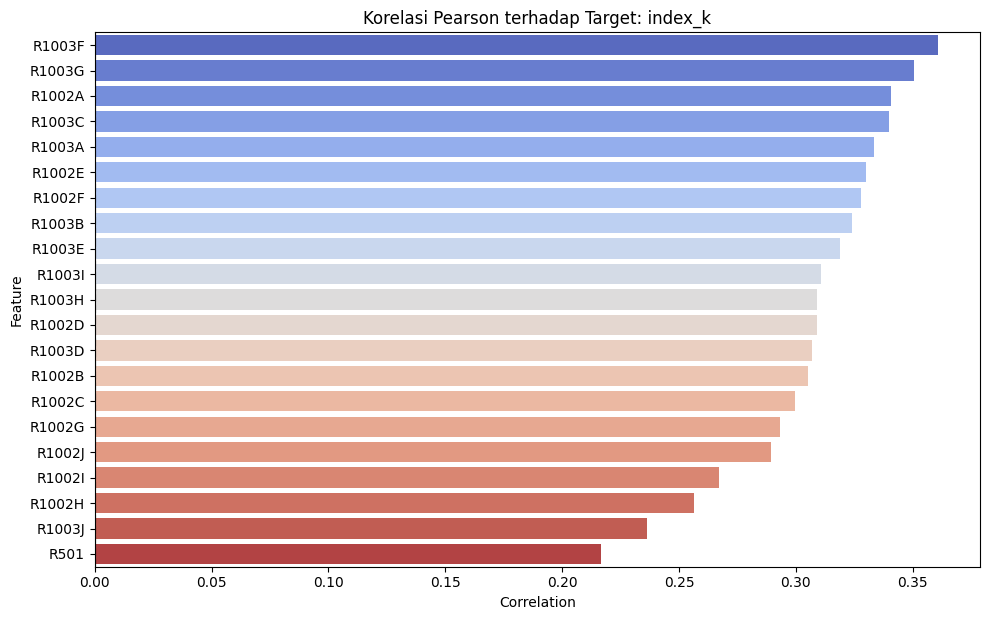

In [641]:
# Kolom yang ingin dikecualikan
excluded_cols = ['index_k_raw', 'URUT', 'WEIGHT']

# Ambil hanya kolom yang bukan target atau excluded
cols_to_check = [col for col in df_final_robust.columns if col not in excluded_cols + ['index_k']]

# Hitung korelasi terhadap target
correlations = df_final_robust[cols_to_check].corrwith(df_final_robust['index_k'])

# Buat DataFrame dari hasil korelasi
corr_df = correlations.dropna().sort_values(ascending=False).reset_index()
corr_df.columns = ['Feature', 'Correlation']

# (Opsional) Filter hanya korelasi dengan |r| > threshold
threshold = 0.2
corr_df_filtered = corr_df[abs(corr_df['Correlation']) > threshold]

# Plot
plt.figure(figsize=(10, len(corr_df_filtered) * 0.3))
sns.barplot(data=corr_df_filtered, x='Correlation', y='Feature', hue='Feature', palette='coolwarm', legend=False)
plt.title('Korelasi Pearson terhadap Target: index_k')
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()


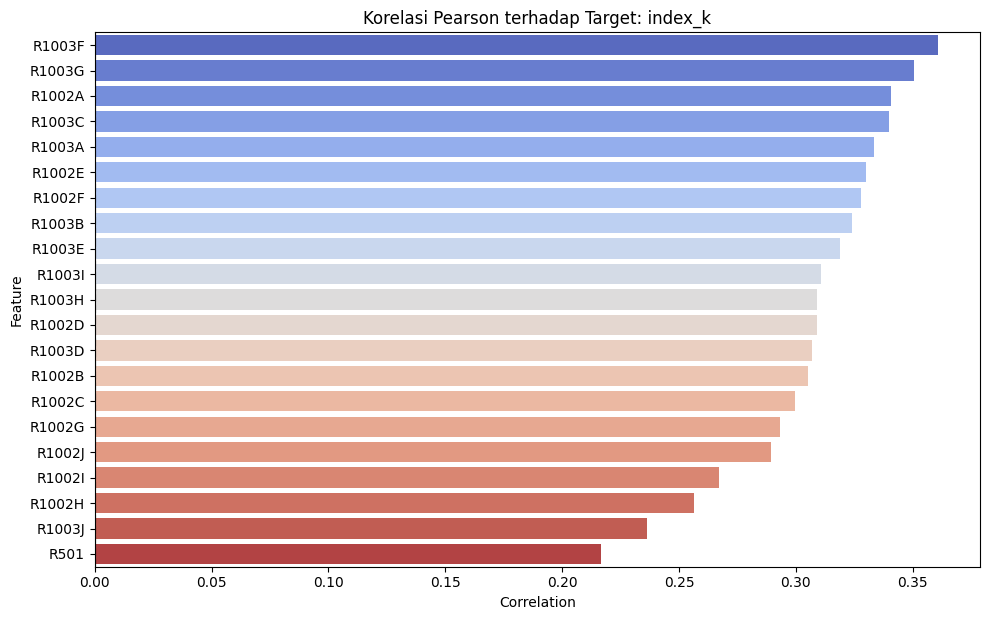

In [ ]:
# Kolom yang ingin dikecualikan
excluded_cols = ['index_k_raw', 'URUT', 'WEIGHT']

# Ambil hanya kolom yang bukan target atau excluded
cols_to_check = [col for col in df_final_standard.columns if col not in excluded_cols + ['index_k']]

# Hitung korelasi terhadap target
correlations = df_final_standard[cols_to_check].corrwith(df_final_standard['index_k'])

# Buat DataFrame dari hasil korelasi
corr_df = correlations.dropna().sort_values(ascending=False).reset_index()
corr_df.columns = ['Feature', 'Correlation']

# (Opsional) Filter hanya korelasi dengan |r| > threshold
threshold = 0.2
corr_df_filtered = corr_df[abs(corr_df['Correlation']) > threshold]

# Plot
plt.figure(figsize=(10, len(corr_df_filtered) * 0.3))
sns.barplot(data=corr_df_filtered, x='Correlation', y='Feature', hue='Feature', palette='coolwarm', legend=False)
plt.title('Korelasi Pearson terhadap Target: index_k_raw')
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()


In [643]:
len(corr_df)

472

## Scaling Dengan Mengabungkan Fitur Berdasarkan Prefix

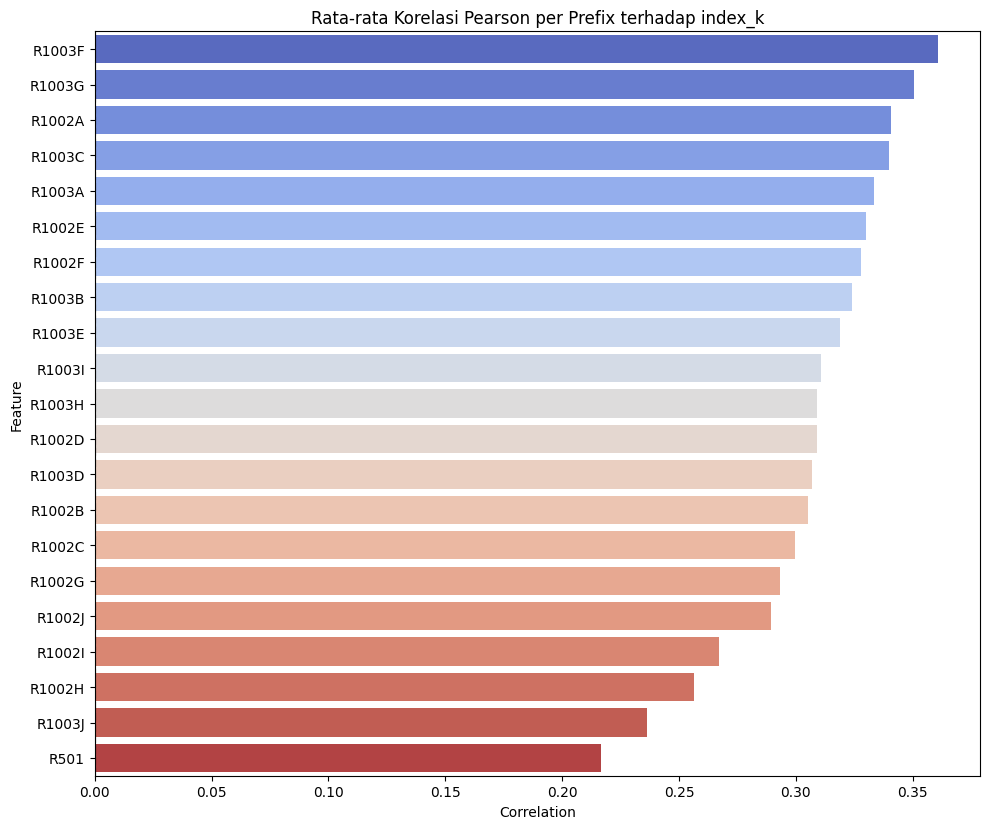

In [644]:
# Kolom yang ingin dikecualikan
excluded_cols = ['index_k_raw', 'URUT', 'WEIGHT']

# Ambil hanya kolom yang bukan target atau excluded
cols_to_check = [col for col in df_final_robust.columns if col not in excluded_cols + ['index_k']]

# Buang kolom dengan std = 0 agar tidak error
df_valid = df_final_robust[cols_to_check].loc[:, df_final_robust[cols_to_check].std() > 0]

# Hitung korelasi terhadap target
correlations = df_valid.corrwith(df_final_robust['index_k'])

# Gabungkan nama fitur berdasarkan prefix sebelum underscore
grouped_corr = correlations.dropna().reset_index()
grouped_corr.columns = ['Feature', 'Correlation']
grouped_corr['Prefix'] = grouped_corr['Feature'].str.extract(r'^([^_]+)')

# Rata-rata korelasi per prefix
agg_corr = grouped_corr.groupby('Prefix')['Correlation'].mean().sort_values(ascending=False).reset_index()

# Filter berdasarkan threshold
threshold = 0.2
agg_corr_filtered = agg_corr[agg_corr['Correlation'].abs() > threshold]

# Plot
plt.figure(figsize=(10, len(agg_corr_filtered) * 0.4))
sns.barplot(data=corr_df_filtered, x='Correlation', y='Feature', hue='Feature', palette='coolwarm', legend=False)
plt.title('Rata-rata Korelasi Pearson per Prefix terhadap index_k')
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

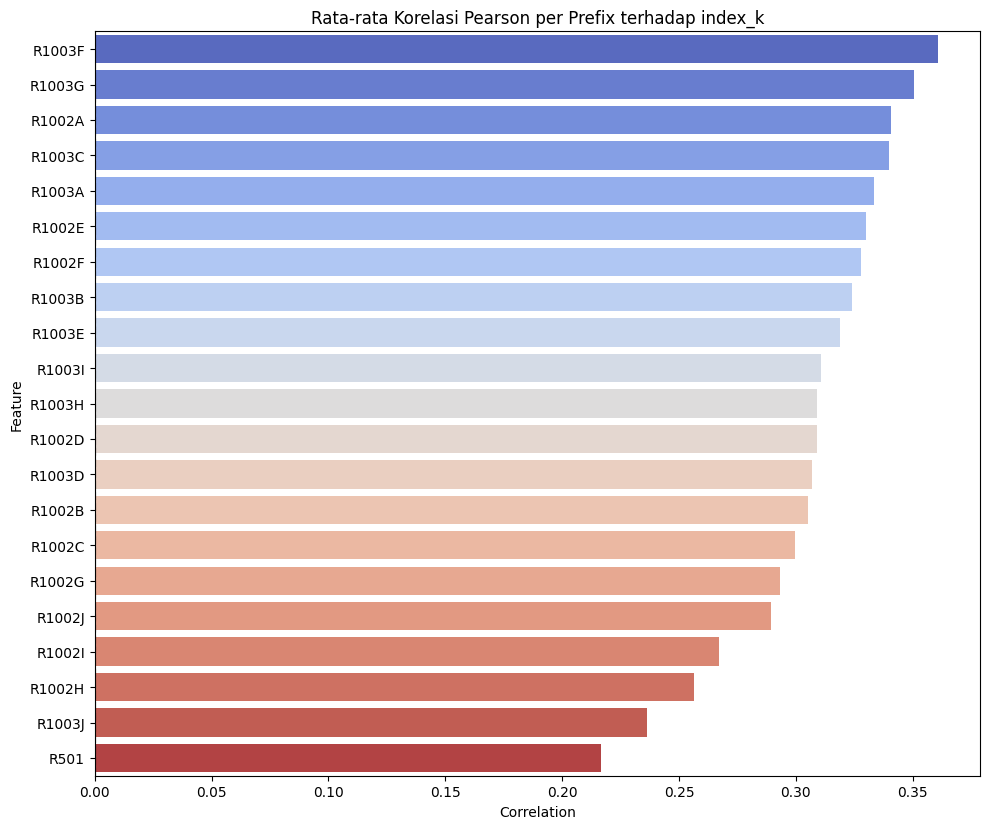

In [645]:
# Kolom yang ingin dikecualikan
excluded_cols = ['index_k_raw', 'URUT', 'WEIGHT']

# Ambil hanya kolom yang bukan target atau excluded
cols_to_check = [col for col in df_final_standard.columns if col not in excluded_cols + ['index_k']]

# Buang kolom dengan std = 0 agar tidak error
df_valid = df_final_standard[cols_to_check].loc[:, df_final_standard[cols_to_check].std() > 0]

# Hitung korelasi terhadap target
correlations = df_valid.corrwith(df_final_standard['index_k'])

# Gabungkan nama fitur berdasarkan prefix sebelum underscore
grouped_corr = correlations.dropna().reset_index()
grouped_corr.columns = ['Feature', 'Correlation']
grouped_corr['Prefix'] = grouped_corr['Feature'].str.extract(r'^([^_]+)')

# Rata-rata korelasi per prefix
agg_corr = grouped_corr.groupby('Prefix')['Correlation'].mean().sort_values(ascending=False).reset_index()

# Filter berdasarkan threshold
threshold = 0.2
agg_corr_filtered = agg_corr[agg_corr['Correlation'].abs() > threshold]

# Plot
plt.figure(figsize=(10, len(agg_corr_filtered) * 0.4))
sns.barplot(data=corr_df_filtered, x='Correlation', y='Feature', hue='Feature', palette='coolwarm', legend=False)
plt.title('Rata-rata Korelasi Pearson per Prefix terhadap index_k')
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

In [646]:
len(agg_corr)

253

# Export to csv

In [647]:
df_final_robust.to_csv('../data/dataset_clean_robust.csv', index=False)
df_final_standard.to_csv('../data/dataset_clean_standard.csv', index=False)

# df.to_csv('../data/dataset_collection.csv', index=False)